**End-to-End Sales Forecasting & Demand Intelligence System**

Task 1 — Data Loading, Merging & Deep Exploration

Superstore shape: (9800, 18)
VGSales shape: (20378, 11)

Missing values:
 Postal Code    11
dtype: int64
Duplicates: 0

Merged multi-source data:
      Year  Superstore_Sales  VG_Global_Sales
0  2015.0       479856.2081           271.26
1  2016.0       459436.0054            75.56
2  2017.0       600192.5500             0.10

Q1 - Revenue by category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Q2 - Growth consistency (lower std = more consistent):
 Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64

Q3 - Avg shipping days by region:
 Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDays, dtype: float64

Q4 - Avg sales by month:
 Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.92225

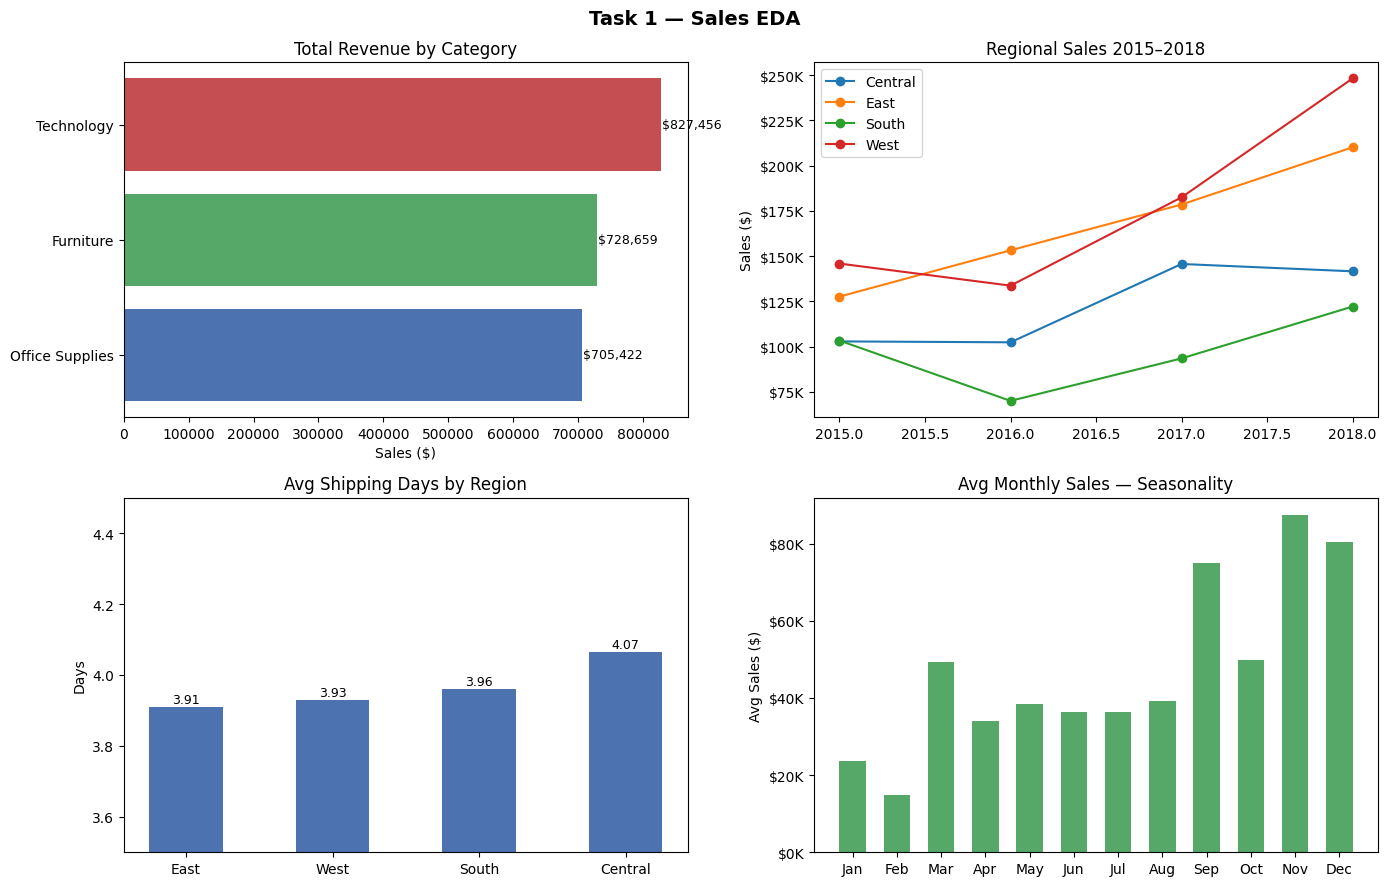

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('charts', exist_ok=True)

df = pd.read_csv('/content/train.csv')
vg = pd.read_csv('/content/vgsales.csv')

print("Superstore shape:", df.shape)
print("VGSales shape:", vg.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicates:", df.duplicated().sum())

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month
df['Week']      = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter']   = df['Order Date'].dt.quarter
df['Season']    = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
     3:'Spring', 4:'Spring', 5:'Spring',
     6:'Summer', 7:'Summer', 8:'Summer',
     9:'Fall',  10:'Fall',  11:'Fall'
})

superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()
superstore_yearly['Year'] = superstore_yearly['Year'].astype(float)
vg_yearly = vg.groupby('Year')['Global_Sales'].sum().reset_index()
merged = pd.merge(superstore_yearly, vg_yearly, on='Year', how='inner')
merged.columns = ['Year', 'Superstore_Sales', 'VG_Global_Sales']
print("\nMerged multi-source data:\n", merged)

monthly = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().reset_index()
monthly.columns = ['Month', 'Total_Sales']

weekly = df.groupby(pd.Grouper(key='Order Date', freq='W-MON'))['Sales'].sum().reset_index()
weekly.columns = ['Week', 'Total_Sales']

monthly.to_csv('monthly_sales.csv', index=False)
weekly.to_csv('weekly_sales.csv', index=False)

df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days
df.to_csv('train_processed.csv', index=False)

cat_rev     = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
pivot       = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
yoy_growth  = pivot.pct_change(axis=1).iloc[:, 1:]
ship_region = df.groupby('Region')['ShipDays'].mean().sort_values()
month_avg   = df.groupby(['Year', 'Month'])['Sales'].sum().groupby('Month').mean()

print("\nQ1 - Revenue by category:\n", cat_rev)
print("\nQ2 - Growth consistency (lower std = more consistent):\n", yoy_growth.std(axis=1).sort_values())
print("\nQ3 - Avg shipping days by region:\n", ship_region)
print("\nQ4 - Avg sales by month:\n", month_avg.sort_values(ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Task 1 — Sales EDA', fontsize=14, fontweight='bold')

cat_sorted = df.groupby('Category')['Sales'].sum().sort_values()
axes[0,0].barh(cat_sorted.index, cat_sorted.values, color=['#4C72B0','#55A868','#C44E52'])
axes[0,0].set_title('Total Revenue by Category')
axes[0,0].set_xlabel('Sales ($)')
for i, v in enumerate(cat_sorted.values):
    axes[0,0].text(v+2000, i, f'${v:,.0f}', va='center', fontsize=9)

for region in pivot.index:
    axes[0,1].plot(pivot.columns, pivot.loc[region], marker='o', label=region)
axes[0,1].set_title('Regional Sales 2015–2018')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].legend()
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

axes[1,0].bar(ship_region.index, ship_region.values, color='#4C72B0', width=0.5)
axes[1,0].set_title('Avg Shipping Days by Region')
axes[1,0].set_ylabel('Days')
axes[1,0].set_ylim(3.5, 4.5)
for i, (reg, val) in enumerate(ship_region.items()):
    axes[1,0].text(i, val+0.01, f'{val:.2f}', ha='center', fontsize=9)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,1].bar(range(1,13), month_avg.values, color='#55A868', width=0.6)
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(month_names)
axes[1,1].set_title('Avg Monthly Sales — Seasonality')
axes[1,1].set_ylabel('Avg Sales ($)')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('charts/task1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

Task 2 — Time Series Analysis & Decomposition

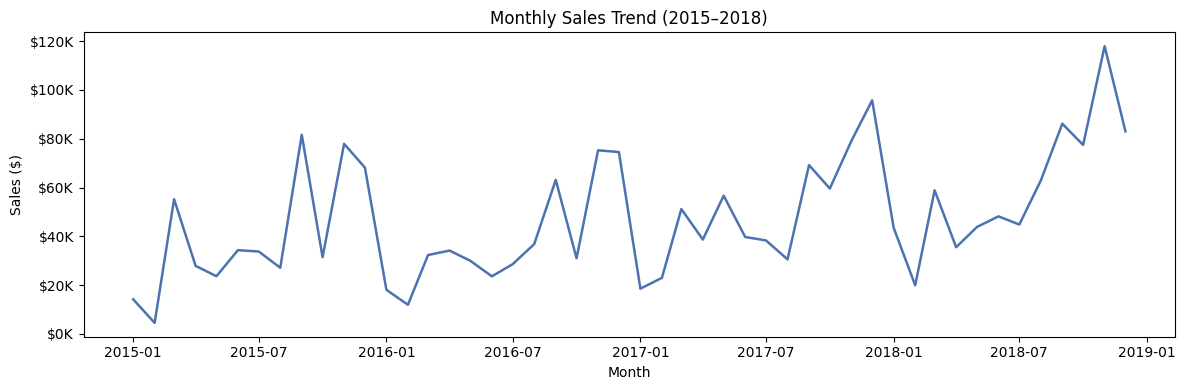

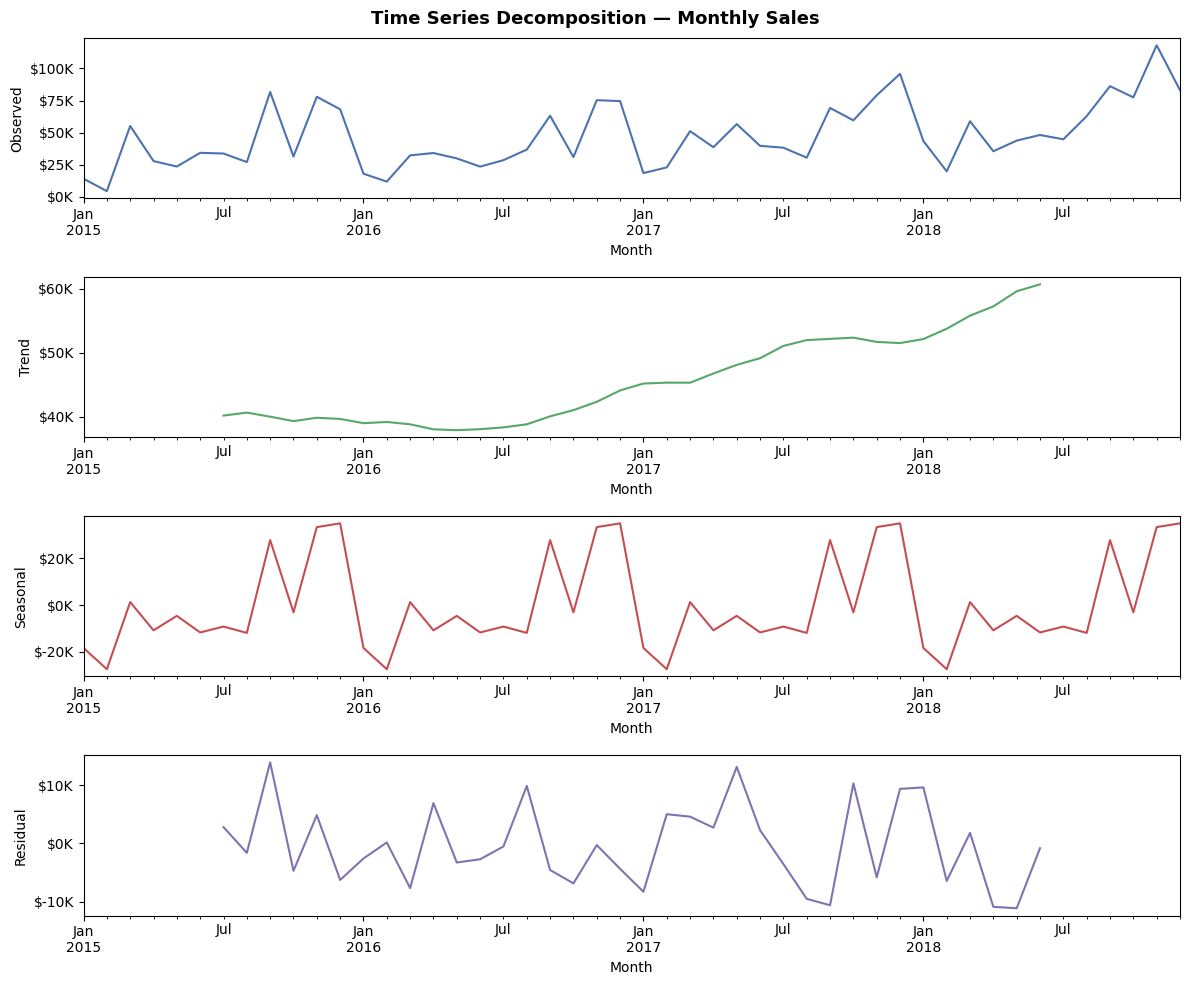


ADF Test — Original Series
ADF Statistic : -4.4161
p-value       : 0.0003
Stationary    : True

ADF Test — After 1st Differencing
ADF Statistic : -8.7271
p-value       : 0.0000
Stationary    : True


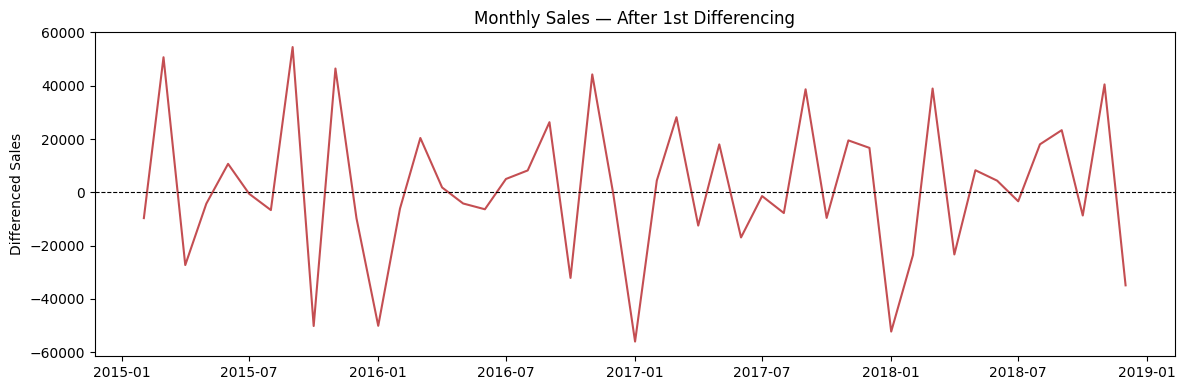

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

monthly = pd.read_csv('monthly_sales.csv', parse_dates=['Month'])
monthly.set_index('Month', inplace=True)

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly['Total_Sales'], color='#4C72B0', linewidth=1.8)
plt.title('Monthly Sales Trend (2015–2018)')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('charts/task2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

decomposition = seasonal_decompose(monthly['Total_Sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
fig.suptitle('Time Series Decomposition — Monthly Sales', fontsize=13, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='#4C72B0')
axes[0].set_ylabel('Observed')

decomposition.trend.plot(ax=axes[1], color='#55A868')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='#C44E52')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='#8172B2')
axes[3].set_ylabel('Residual')

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('charts/task2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

def adf_test(series, label=''):
    result = adfuller(series.dropna())
    print(f'\nADF Test — {label}')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Stationary    : {result[1] < 0.05}')

adf_test(monthly['Total_Sales'], 'Original Series')

monthly['Sales_Diff'] = monthly['Total_Sales'].diff()
adf_test(monthly['Sales_Diff'], 'After 1st Differencing')

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly['Sales_Diff'], color='#C44E52', linewidth=1.5)
plt.title('Monthly Sales — After 1st Differencing')
plt.ylabel('Differenced Sales')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('charts/task2_differenced.png', dpi=150, bbox_inches='tight')
plt.show()

Task 3 — Sales Forecasting using 3 Different Models

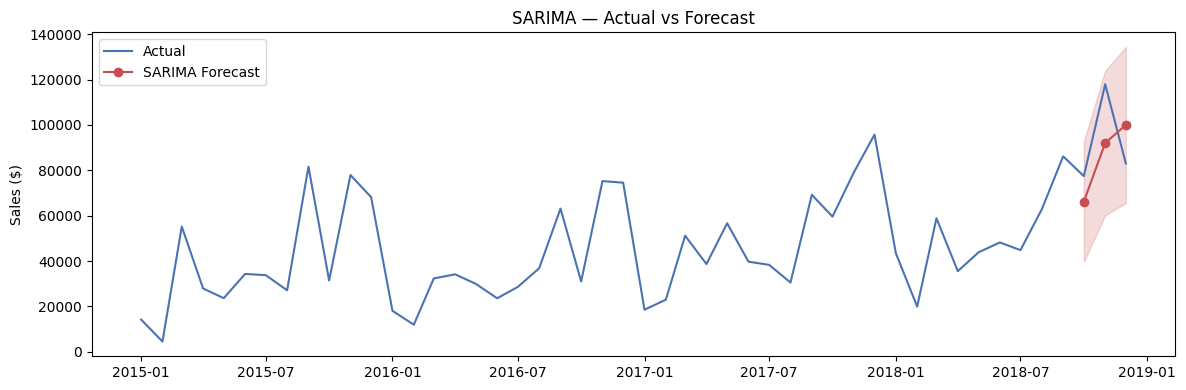

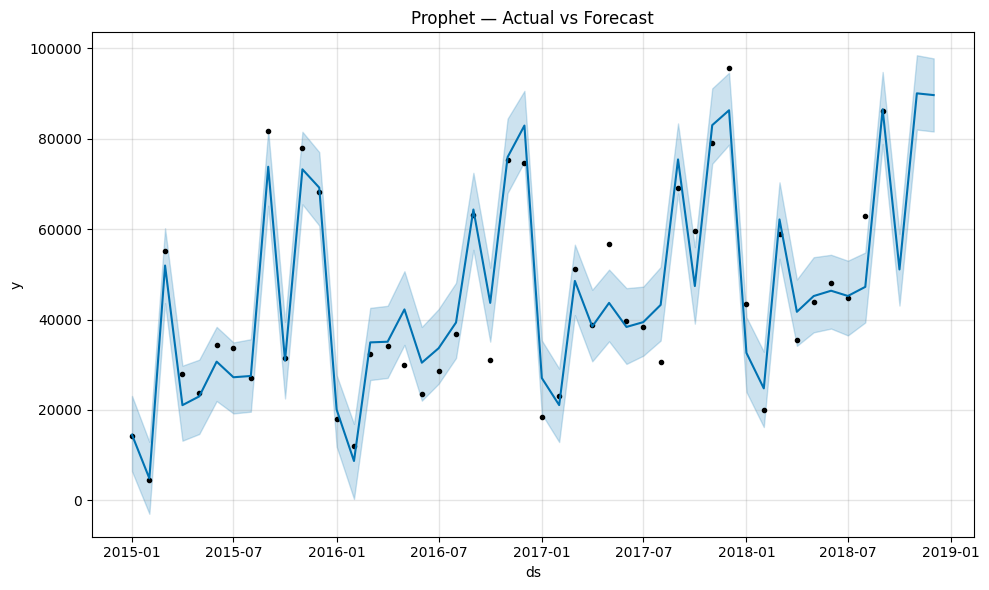

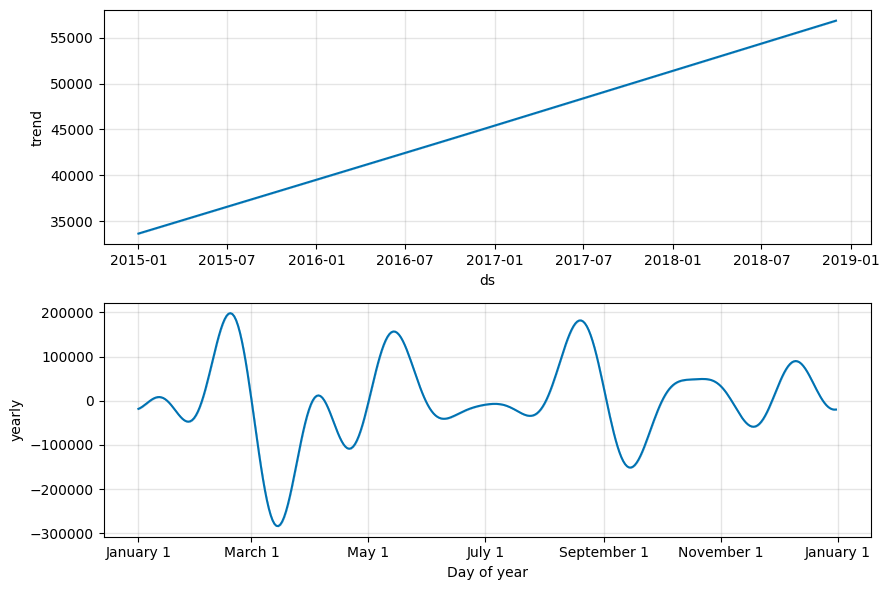

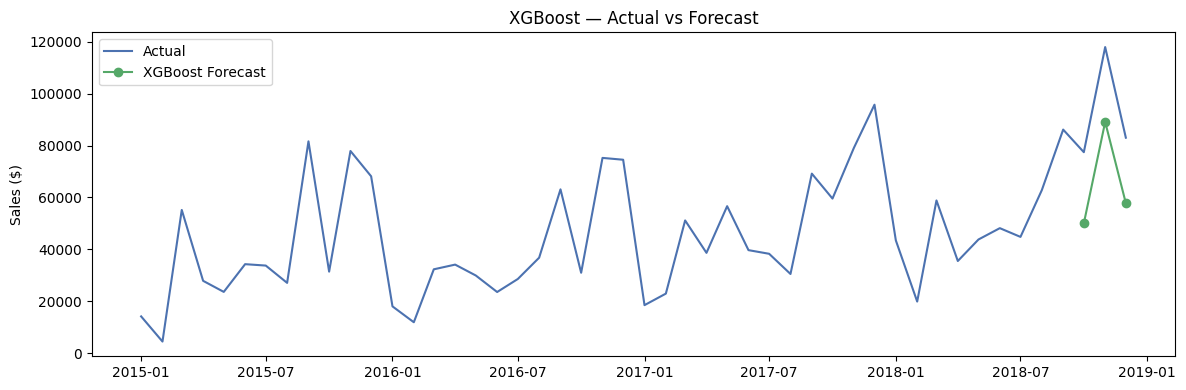

  Model      MAE     RMSE  MAPE (%)      Month 1    Month 2      Month 3
 SARIMA 18031.40 19009.18     18.97 66177.600000 92049.2500 99965.170000
Prophet 20296.01 22487.47     21.89 51083.660000 90045.4000 89661.190000
XGBoost 27153.68 27194.67     30.07 50040.839844 89096.6875 57818.101562


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

monthly = pd.read_csv('monthly_sales.csv', parse_dates=['Month'])
monthly.set_index('Month', inplace=True)

train = monthly.iloc[:-3]
test  = monthly.iloc[-3:]

sarima_model = SARIMAX(train['Total_Sales'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit   = sarima_model.fit(disp=False)
sarima_pred  = sarima_fit.forecast(steps=3)
sarima_conf  = sarima_fit.get_forecast(steps=3).conf_int()

sarima_mae  = mean_absolute_error(test['Total_Sales'], sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test['Total_Sales'], sarima_pred))
sarima_mape = np.mean(np.abs((test['Total_Sales'].values - sarima_pred.values) / test['Total_Sales'].values)) * 100

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly['Total_Sales'], label='Actual', color='#4C72B0')
plt.plot(test.index, sarima_pred, label='SARIMA Forecast', color='#C44E52', marker='o')
plt.fill_between(test.index, sarima_conf.iloc[:,0], sarima_conf.iloc[:,1], alpha=0.2, color='#C44E52')
plt.title('SARIMA — Actual vs Forecast')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task3_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

prophet_df    = monthly.reset_index().rename(columns={'Month':'ds','Total_Sales':'y'})
prophet_train = prophet_df.iloc[:-3]
m             = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)
future        = m.make_future_dataframe(periods=3, freq='MS')
forecast      = m.predict(future)
prophet_pred  = forecast.iloc[-3:]['yhat'].values

prophet_mae  = mean_absolute_error(test['Total_Sales'], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test['Total_Sales'], prophet_pred))
prophet_mape = np.mean(np.abs((test['Total_Sales'].values - prophet_pred) / test['Total_Sales'].values)) * 100

m.plot(forecast)
plt.title('Prophet — Actual vs Forecast')
plt.tight_layout()
plt.savefig('charts/task3_prophet.png', dpi=150, bbox_inches='tight')
plt.show()

m.plot_components(forecast)
plt.tight_layout()
plt.savefig('charts/task3_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

def make_features(df):
    df = df.copy()
    df['lag1']    = df['Total_Sales'].shift(1)
    df['lag2']    = df['Total_Sales'].shift(2)
    df['lag3']    = df['Total_Sales'].shift(3)
    df['roll3']   = df['Total_Sales'].shift(1).rolling(3).mean()
    df['month']   = df.index.month
    df['quarter'] = df.index.quarter
    df['season']  = df['month'].map({12:4,1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
    return df.dropna()

monthly_feat = make_features(monthly)
features     = ['lag1','lag2','lag3','roll3','month','quarter','season']

X_train = monthly_feat.iloc[:-3][features]
y_train = monthly_feat.iloc[:-3]['Total_Sales']
X_test  = monthly_feat.iloc[-3:][features]
y_test  = monthly_feat.iloc[-3:]['Total_Sales']

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly['Total_Sales'], label='Actual', color='#4C72B0')
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast', color='#55A868', marker='o')
plt.title('XGBoost — Actual vs Forecast')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task3_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

comparison = pd.DataFrame({
    'Model'    : ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE'      : [round(sarima_mae,2), round(prophet_mae,2), round(xgb_mae,2)],
    'RMSE'     : [round(sarima_rmse,2), round(prophet_rmse,2), round(xgb_rmse,2)],
    'MAPE (%)'  : [round(sarima_mape,2), round(prophet_mape,2), round(xgb_mape,2)],
    'Month 1'  : [round(sarima_pred.iloc[0],2), round(prophet_pred[0],2), round(xgb_pred[0],2)],
    'Month 2'  : [round(sarima_pred.iloc[1],2), round(prophet_pred[1],2), round(xgb_pred[1],2)],
    'Month 3'  : [round(sarima_pred.iloc[2],2), round(prophet_pred[2],2), round(xgb_pred[2],2)],
})

print(comparison.to_string(index=False))

Task 4 — Product Category & Region Level Forecasting

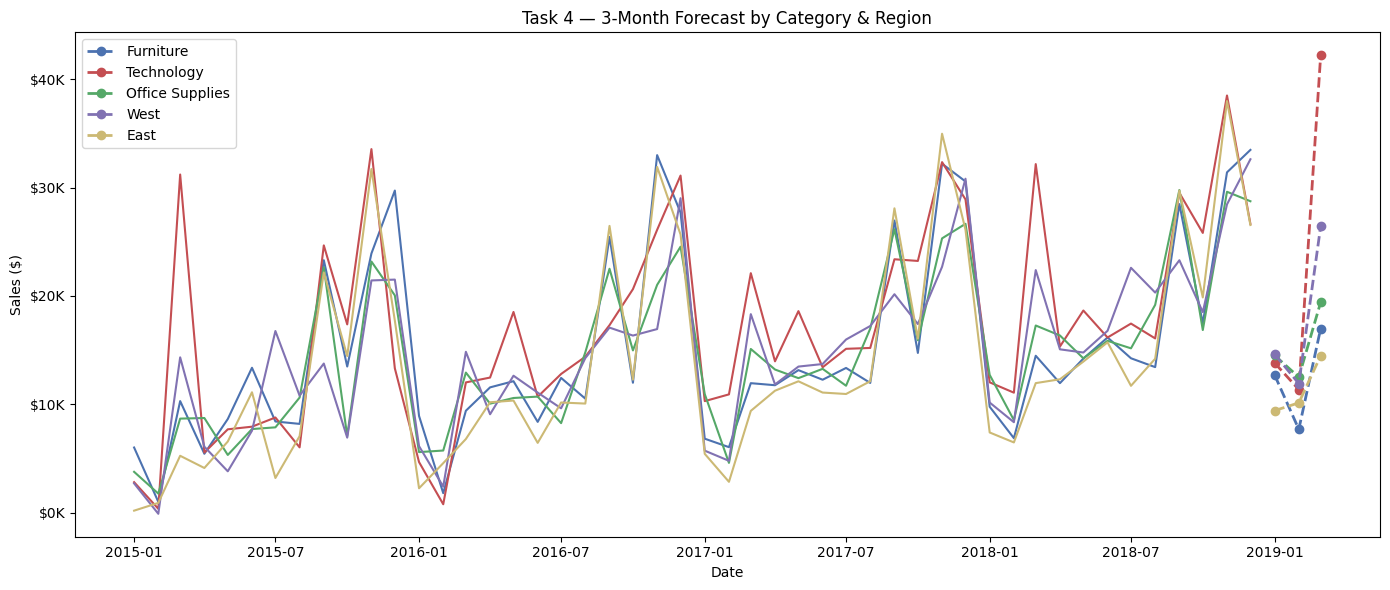


Forecast Summary (next 3 months):
Furniture            → 12,703 | 7,687 | 16,989
Technology           → 13,816 | 11,357 | 42,216
Office Supplies      → 14,509 | 12,500 | 19,422
West                 → 14,626 | 11,908 | 26,433
East                 → 9,412 | 10,128 | 14,478


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train_processed.csv', parse_dates=['Order Date'])

segments = {
    'Furniture'      : df[df['Category'] == 'Furniture'],
    'Technology'     : df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West'           : df[df['Region'] == 'West'],
    'East'           : df[df['Region'] == 'East'],
}

forecasts = {}

for name, data in segments.items():
    monthly = data.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().reset_index()
    monthly.columns = ['ds', 'y']

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(monthly)

    future   = m.make_future_dataframe(periods=3, freq='MS')
    forecast = m.predict(future)
    forecasts[name] = forecast[['ds', 'yhat']].set_index('ds')

colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B2', '#CCB974']

plt.figure(figsize=(14, 6))
for (name, fc), color in zip(forecasts.items(), colors):
    hist = fc.iloc[:-3]
    pred = fc.iloc[-3:]
    plt.plot(hist.index, hist['yhat'], color=color, linewidth=1.5)
    plt.plot(pred.index, pred['yhat'], color=color, linewidth=2, linestyle='--', marker='o', label=name)

plt.title('Task 4 — 3-Month Forecast by Category & Region')
plt.ylabel('Sales ($)')
plt.xlabel('Date')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('charts/task4_segment_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nForecast Summary (next 3 months):")
for name, fc in forecasts.items():
    pred = fc.iloc[-3:]['yhat'].values
    print(f"{name:20s} → {pred[0]:,.0f} | {pred[1]:,.0f} | {pred[2]:,.0f}")

Task 5 — Anomaly Detection in Sales Data

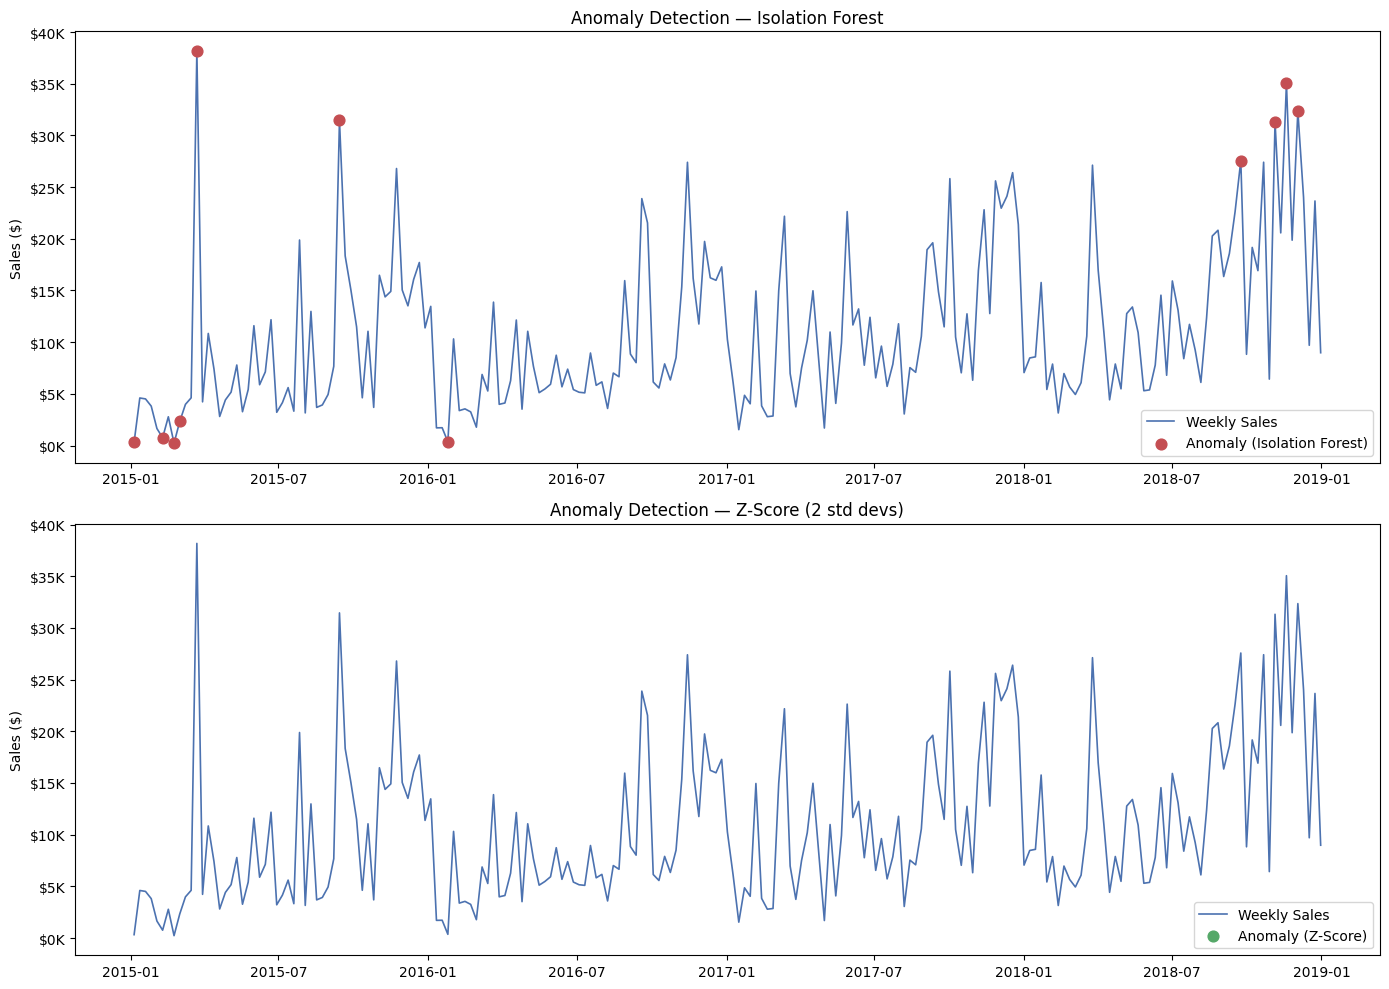

Isolation Forest anomalies:
            Total_Sales
Week                   
2015-01-05      324.044
2015-02-09      756.888
2015-02-23      227.236
2015-03-02     2326.039
2015-03-23    38176.809
2015-09-14    31458.978
2016-01-25      358.522
2018-09-24    27575.669
2018-11-05    31325.571
2018-11-19    35058.333
2018-12-03    32354.570

Z-Score anomalies:
Empty DataFrame
Columns: [Total_Sales, zscore]
Index: []

Agreed on    : []
Only ISO     : ['2015-01-05', '2015-02-09', '2015-02-23', '2015-03-02', '2015-03-23', '2015-09-14', '2016-01-25', '2018-09-24', '2018-11-05', '2018-11-19', '2018-12-03']
Only Z-Score : []


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

weekly = pd.read_csv('weekly_sales.csv', parse_dates=['Week'])
weekly.set_index('Week', inplace=True)

iso = IsolationForest(contamination=0.05, random_state=42)
weekly['iso_anomaly'] = iso.fit_predict(weekly[['Total_Sales']])
weekly['iso_flag'] = weekly['iso_anomaly'] == -1

weekly['rolling_mean'] = weekly['Total_Sales'].rolling(4).mean()
weekly['rolling_std']  = weekly['Total_Sales'].rolling(4).std()
weekly['zscore']       = (weekly['Total_Sales'] - weekly['rolling_mean']) / weekly['rolling_std']
weekly['z_flag']       = weekly['zscore'].abs() > 2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(weekly.index, weekly['Total_Sales'], color='#4C72B0', linewidth=1.2, label='Weekly Sales')
axes[0].scatter(weekly[weekly['iso_flag']].index, weekly[weekly['iso_flag']]['Total_Sales'],
                color='#C44E52', zorder=5, s=60, label='Anomaly (Isolation Forest)')
axes[0].set_title('Anomaly Detection — Isolation Forest')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

axes[1].plot(weekly.index, weekly['Total_Sales'], color='#4C72B0', linewidth=1.2, label='Weekly Sales')
axes[1].scatter(weekly[weekly['z_flag']].index, weekly[weekly['z_flag']]['Total_Sales'],
                color='#55A868', zorder=5, s=60, label='Anomaly (Z-Score)')
axes[1].set_title('Anomaly Detection — Z-Score (2 std devs)')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('charts/task5_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

iso_dates = weekly[weekly['iso_flag']].index.tolist()
z_dates   = weekly[weekly['z_flag']].index.tolist()

both   = set([str(d.date()) for d in iso_dates]) & set([str(d.date()) for d in z_dates])
only_iso = set([str(d.date()) for d in iso_dates]) - both
only_z   = set([str(d.date()) for d in z_dates]) - both

print("Isolation Forest anomalies:")
print(weekly[weekly['iso_flag']][['Total_Sales']].to_string())

print("\nZ-Score anomalies:")
print(weekly[weekly['z_flag']][['Total_Sales', 'zscore']].to_string())

print(f"\nAgreed on    : {sorted(both)}")
print(f"Only ISO     : {sorted(only_iso)}")
print(f"Only Z-Score : {sorted(only_z)}")

Task 6 — Product Demand Segmentation using Clustering

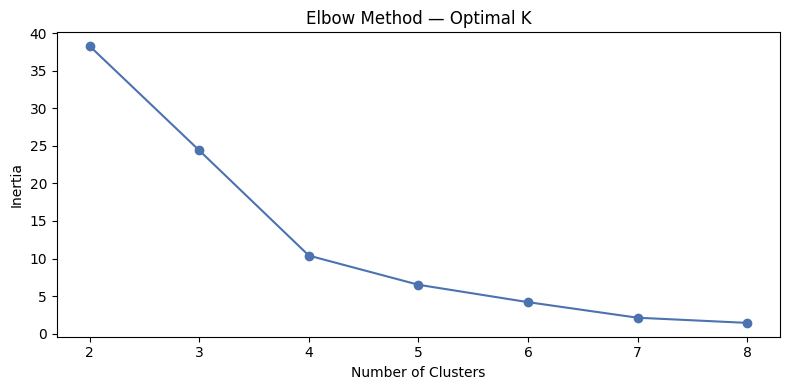

           Total_Sales    Avg_Order   Volatility  Growth_Rate
Cluster                                                      
0        167743.362500  1930.716763  5552.164569     0.463389
1         55331.883212   129.054568   907.223743     0.199589
2        239495.780667   361.131228  3489.056075     0.180965
3         46420.308000   252.284283  2025.094139     1.928448


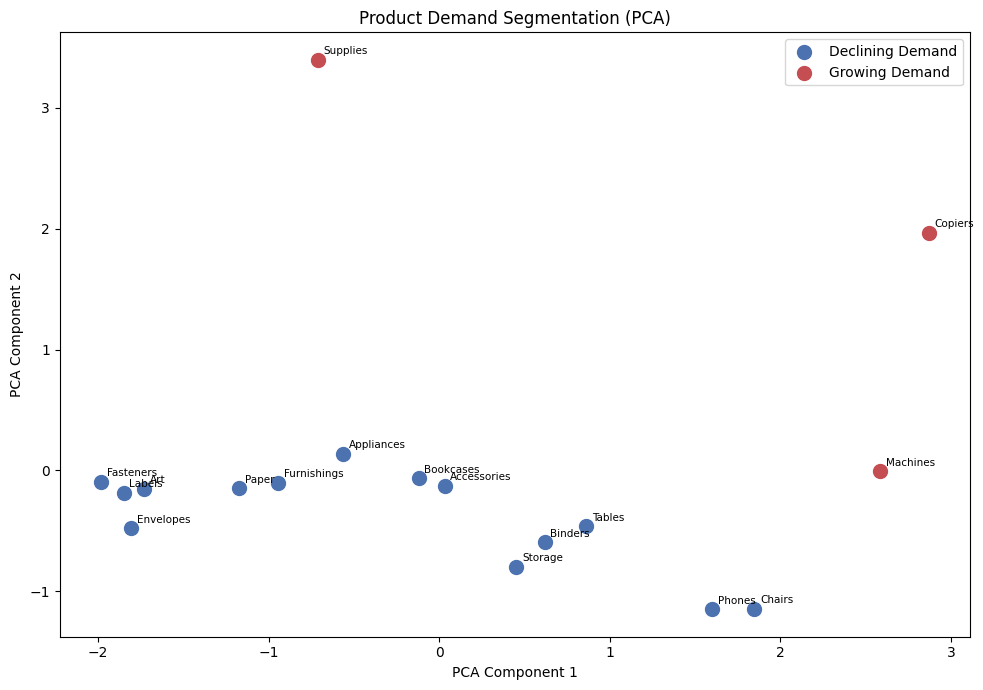


Sub-category cluster assignments:
                         Label
Sub-Category                  
Accessories   Declining Demand
Storage       Declining Demand
Phones        Declining Demand
Paper         Declining Demand
Labels        Declining Demand
Furnishings   Declining Demand
Envelopes     Declining Demand
Fasteners     Declining Demand
Chairs        Declining Demand
Bookcases     Declining Demand
Binders       Declining Demand
Art           Declining Demand
Appliances    Declining Demand
Tables        Declining Demand
Supplies        Growing Demand
Machines        Growing Demand
Copiers         Growing Demand


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train_processed.csv', parse_dates=['Order Date'])

total_sales    = df.groupby('Sub-Category')['Sales'].sum()
avg_order      = df.groupby('Sub-Category')['Sales'].mean()
volatility     = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().groupby('Sub-Category').std()

yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
growth = yearly.pct_change(axis=1).iloc[:, 1:].mean(axis=1)

features = pd.DataFrame({
    'Total_Sales' : total_sales,
    'Avg_Order'   : avg_order,
    'Volatility'  : volatility,
    'Growth_Rate' : growth
}).dropna()

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(features)

inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='#4C72B0')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('charts/task6_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
features['Cluster'] = km_final.fit_predict(X_scaled)

cluster_summary = features.groupby('Cluster').mean()
print(cluster_summary)

label_map = {}
for cluster in features['Cluster'].unique():
    c = cluster_summary.loc[cluster]
    if c['Total_Sales'] > cluster_summary['Total_Sales'].median() and c['Volatility'] < cluster_summary['Volatility'].median():
        label_map[cluster] = 'High Volume, Stable Demand'
    elif c['Growth_Rate'] > cluster_summary['Growth_Rate'].median():
        label_map[cluster] = 'Growing Demand'
    elif c['Total_Sales'] < cluster_summary['Total_Sales'].median() and c['Volatility'] > cluster_summary['Volatility'].median():
        label_map[cluster] = 'Low Volume, High Volatility'
    else:
        label_map[cluster] = 'Declining Demand'

features['Label'] = features['Cluster'].map(label_map)

pca    = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
features['PCA1'] = coords[:, 0]
features['PCA2'] = coords[:, 1]

colors = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']
fig, ax = plt.subplots(figsize=(10, 7))

for i, (label, group) in enumerate(features.groupby('Label')):
    ax.scatter(group['PCA1'], group['PCA2'], label=label, color=colors[i], s=100, zorder=3)
    for subcat, row in group.iterrows():
        ax.annotate(subcat, (row['PCA1'], row['PCA2']), fontsize=7.5,
                    xytext=(4, 4), textcoords='offset points')

ax.set_title('Product Demand Segmentation (PCA)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend()
plt.tight_layout()
plt.savefig('charts/task6_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSub-category cluster assignments:")
print(features[['Label']].sort_values('Label').to_string())

Task 7 — Deployment: Interactive Dashboard using Streamlit

In app.py